In [1]:
import pandas as pd
import numpy as np

from SCIKIT.Lesson4Pipelines import Y_train, X_test, Y_test
from sklearn.pipeline import Pipeline

data = {
    "bedrooms": [2, 3, 4, 3, 5, 2, 4, 3, 5, 4],
    "area": [900, 1200, np.nan, 1400, 2200, 850, 1700, np.nan, 2400, 1900],
    "age": [15, 10, 5, 8, 3, np.nan, 6, 12, 2, 4],
    "location": [
        "Islamabad",
        "Lahore",
        "Islamabad",
        "Karachi",
        "Lahore",
        "Karachi",
        "Islamabad",
        "Lahore",
        np.nan,
        "Islamabad"
    ],
    "price": [
        12000000,
        15000000,
        22000000,
        16000000,
        28000000,
        10000000,
        21000000,
        15500000,
        30000000,
        23000000
    ]
}

df = pd.DataFrame(data)

df

,bedrooms,area,age,location,price
0,2,900.0,15.0,Islamabad,12000000
1,3,1200.0,10.0,Lahore,15000000
2,4,NaN,5.0,Islamabad,22000000
3,3,1400.0,8.0,Karachi,16000000
4,5,2200.0,3.0,Lahore,28000000
5,2,850.0,NaN,Karachi,10000000
6,4,1700.0,6.0,Islamabad,21000000
7,3,NaN,12.0,Lahore,15500000
8,5,2400.0,2.0,NaN,30000000
9,4,1900.0,4.0,Islamabad,23000000


In [2]:
print(df.isnull().sum())

bedrooms    0
area        2
age         1
location    1
price       0
dtype: int64


In [3]:
X=df.drop("price",axis=1)
Y=df["price"]

In [4]:
from sklearn.model_selection import train_test_split


X_train,Y_train,X_test,Y_test=train_test_split(

    X,
    Y,
    test_size=0.2,
random_state=42



)



In [5]:
numeric_features=["bedrooms", "area", "age"]
categorical_features=["location"]



In [6]:
from sklearn.impute import SimpleImputer
numeric_imputer=SimpleImputer(strategy="median")


In [7]:
categorical_imputer=SimpleImputer(
    strategy="most_frequent"

)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [11]:
from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline([
    "imputer",SimpleImputer(strategy="most_frequent"),
    "encoder",OneHotEncoder(handle_unknown="ignore")

])

In [14]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [15]:
from sklearn.linear_model import Ridge
model=Pipeline([
    ("preprocessor",preprocessor)
,("regressor",Ridge(alpha=1))

]



)

In [20]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


# ============================================
# 2. CREATE DATASET
# ============================================

data = {
    "bedrooms": [2, 3, 4, 3, 5, 2, 4, 3, 5, 4],

    "area": [
        900, 1200, np.nan, 1400, 2200,
        850, 1700, np.nan, 2400, 1900
    ],

    "age": [
        15, 10, 5, 8, 3,
        np.nan, 6, 12, 2, 4
    ],

    "location": [
        "Islamabad",
        "Lahore",
        "Islamabad",
        "Karachi",
        "Lahore",
        "Karachi",
        "Islamabad",
        "Lahore",
        np.nan,
        "Islamabad"
    ],

    "price": [
        12000000,
        15000000,
        22000000,
        16000000,
        28000000,
        10000000,
        21000000,
        15500000,
        30000000,
        23000000
    ]
}

df = pd.DataFrame(data)

print("DATASET:")
print(df)


# ============================================
# 3. CHECK MISSING VALUES
# ============================================

print("\nMISSING VALUES:")
print(df.isnull().sum())


# ============================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================

X = df.drop("price", axis=1)

Y = df["price"]

print("\nFEATURES (X):")
print(X)

print("\nTARGET (Y):")
print(Y)


# ============================================
# 5. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("\nSHAPES:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)


# ============================================
# 6. DEFINE COLUMN TYPES
# ============================================

numeric_features = [
    "bedrooms",
    "area",
    "age"
]

categorical_features = [
    "location"
]


# ============================================
# 7. NUMERICAL PIPELINE
# ============================================
#
# Numerical data:
#
# Missing values
#       ↓
# Median Imputation
#       ↓
# StandardScaler
#

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ============================================
# 8. CATEGORICAL PIPELINE
# ============================================
#
# Categorical data:
#
# Missing values
#       ↓
# Most Frequent Imputation
#       ↓
# OneHotEncoder
#

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# ============================================
# 9. COLUMN TRANSFORMER
# ============================================

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# ============================================
# 10. COMPLETE MACHINE LEARNING PIPELINE
# ============================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "regressor",
        Ridge(alpha=1.0)
    )
])


# ============================================
# 11. TRAIN THE MODEL
# ============================================

model.fit(X_train, Y_train)


# ============================================
# 12. MAKE PREDICTIONS
# ============================================

predictions = model.predict(X_test)

print("\nPREDICTIONS:")
print(predictions)


# ============================================
# 13. ACTUAL VS PREDICTED
# ============================================

comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": predictions
})

print("\nACTUAL VS PREDICTED:")
print(comparison)


# ============================================
# 14. EVALUATION
# ============================================

r2 = r2_score(Y_test, predictions)

mae = mean_absolute_error(
    Y_test,
    predictions
)

mse = mean_squared_error(
    Y_test,
    predictions
)

rmse = np.sqrt(mse)


print("\nMODEL PERFORMANCE:")
print("R²   :", r2)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)


# ============================================
# 15. SEE THE PIPELINE
# ============================================

print("\nCOMPLETE PIPELINE:")
print(model)

DATASET:
   bedrooms    area   age   location     price
0         2   900.0  15.0  Islamabad  12000000
1         3  1200.0  10.0     Lahore  15000000
2         4     NaN   5.0  Islamabad  22000000
3         3  1400.0   8.0    Karachi  16000000
4         5  2200.0   3.0     Lahore  28000000
5         2   850.0   NaN    Karachi  10000000
6         4  1700.0   6.0  Islamabad  21000000
7         3     NaN  12.0     Lahore  15500000
8         5  2400.0   2.0        NaN  30000000
9         4  1900.0   4.0  Islamabad  23000000

MISSING VALUES:
bedrooms    0
area        2
age         1
location    1
price       0
dtype: int64

FEATURES (X):
   bedrooms    area   age   location
0         2   900.0  15.0  Islamabad
1         3  1200.0  10.0     Lahore
2         4     NaN   5.0  Islamabad
3         3  1400.0   8.0    Karachi
4         5  2200.0   3.0     Lahore
5         2   850.0   NaN    Karachi
6         4  1700.0   6.0  Islamabad
7         3     NaN  12.0     Lahore
8         5  2400.0   2.0 

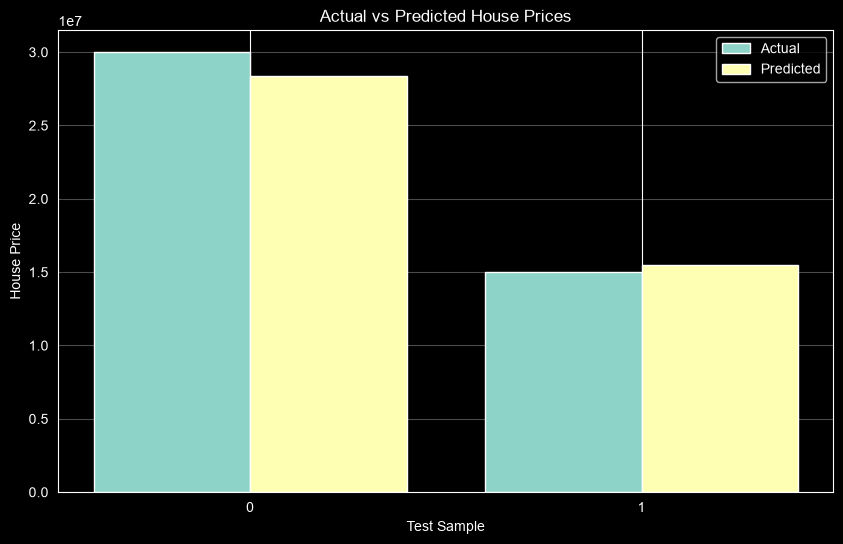

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

x = range(len(Y_test))

plt.bar(
    [i - 0.2 for i in x],
    Y_test.values,
    width=0.4,
    label="Actual"
)

plt.bar(
    [i + 0.2 for i in x],
    predictions,
    width=0.4,
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("House Price")
plt.title("Actual vs Predicted House Prices")

plt.xticks(list(x))
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

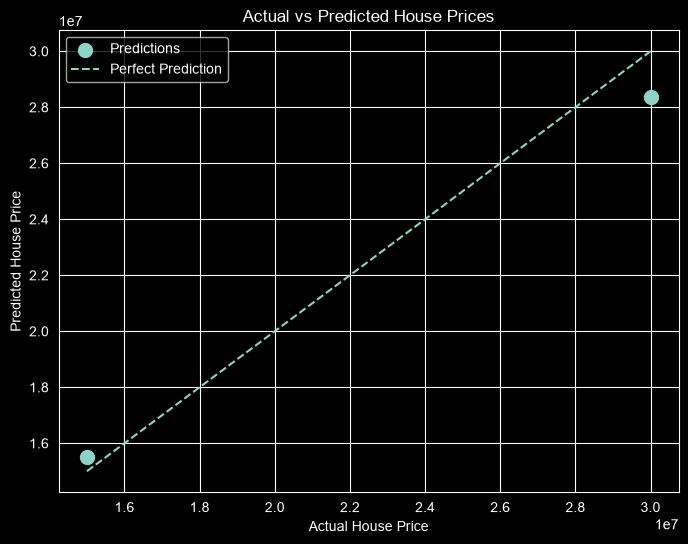

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    Y_test,
    predictions,
    s=100,
    label="Predictions"
)

minimum = min(Y_test.min(), predictions.min())
maximum = max(Y_test.max(), predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.legend()
plt.grid(True)

plt.show()

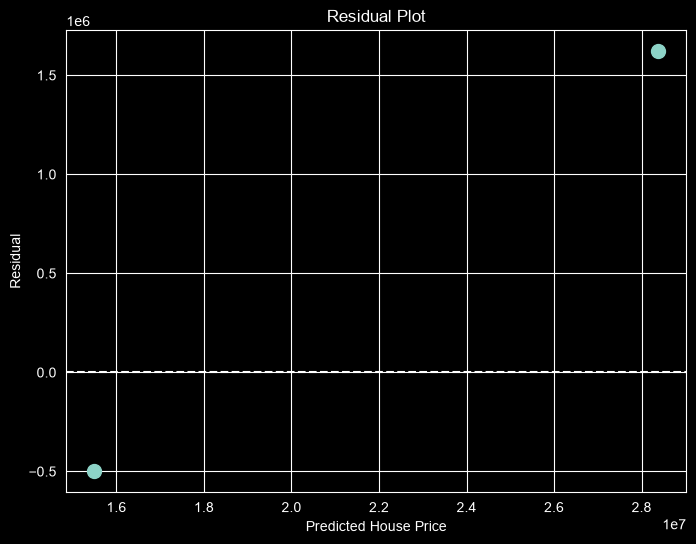

In [23]:
residuals = Y_test.values - predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    predictions,
    residuals,
    s=100
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [25]:
data = {
    "bedrooms": [2, 3, 4, 3, 5, 2, 4, 3, 5, 4],

    "area": [
        900, 1200, np.nan, 1400, 2200,
        850, 1700, np.nan, 2400, 1900
    ],

    "age": [
        15, 10, 5, 8, 3,
        np.nan, 6, 12, 2, 4
    ],

    "location": [
        "Islamabad",
        "Lahore",
        "Islamabad",
        "Karachi",
        "Lahore",
        "Karachi",
        "Islamabad",
        "Lahore",
        np.nan,
        "Islamabad"
    ],

    "price": [
        12000000,
        15000000,
        22000000,
        16000000,
        28000000,
        10000000,
        21000000,
        15500000,
        30000000,
        23000000
    ]
}

df = pd.DataFrame(data)


In [29]:
X=df.drop("price", axis=1)
Y=df["price"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)


In [31]:
print("X_TRAIN:",X_train)
print("X_TEST:",X_test)
print("Y_TRAIN:",Y_train)
print("Y_TEST:",Y_test)

X_TRAIN:    bedrooms    area   age   location
5         2   850.0   NaN    Karachi
0         2   900.0  15.0  Islamabad
7         3     NaN  12.0     Lahore
2         4     NaN   5.0  Islamabad
9         4  1900.0   4.0  Islamabad
4         5  2200.0   3.0     Lahore
3         3  1400.0   8.0    Karachi
6         4  1700.0   6.0  Islamabad
X_TEST:    bedrooms    area   age location
8         5  2400.0   2.0      NaN
1         3  1200.0  10.0   Lahore
Y_TRAIN: 5    10000000
0    12000000
7    15500000
2    22000000
9    23000000
4    28000000
3    16000000
6    21000000
Name: price, dtype: int64
Y_TEST: 8    30000000
1    15000000
Name: price, dtype: int64


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline=Pipeline([(
    "IMPUTER:",SimpleImputer(strategy="median"),
    "Scaler",StandardScaler()


)


])


In [33]:
categorical_pipeline=Pipeline([

    ("IMPUTER:",SimpleImputer(strategy="most_frequent")),
    ("ENCODER",OneHotEncoder(handle_unknown="ignore"))

])

In [36]:
from sklearn.compose import ColumnTransformer
numeric_features=["bedrooms","area","age"

                  ]
categorical_features=["location"]
preprocessor=ColumnTransformer(
    [
        ("numeric",numeric_pipeline,numeric_features),
        ("categorical",categorical_pipeline,categorical_features)



    ]


)


In [38]:
from sklearn.linear_model import Ridge
model=Pipeline([
    ("preprocessor",preprocessor),
    ("regressor",Ridge(alpha=1))

])

In [40]:
model.fit(X_train,Y_train)


ValueError: too many values to unpack (expected 2, got 4)

In [1]:
predictions = model.predict(X_test)

print(predictions)

NameError: name 'model' is not defined